# Manhattan Apartment Rental Price Prediction


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
ACCENT = '#2563EB'
SOFT   = '#93C5FD'



## Data Loading and Cleaning

In [2]:
df_raw = pd.read_csv('manhattan.csv')
print(f'Raw shape: {df_raw.shape}')
print(f'\nColumns:\n{df_raw.dtypes}')
print(f'\nNull counts:\n{df_raw.isnull().sum()}')
print(f'\nSample rows:')
print(df_raw.head(3).to_string())

Raw shape: (3539, 18)

Columns:
rental_id             int64
rent                  int64
bedrooms            float64
bathrooms             int64
size_sqft             int64
min_to_subway         int64
floor               float64
building_age_yrs      int64
no_fee                int64
has_roofdeck          int64
has_washer_dryer      int64
has_doorman           int64
has_elevator          int64
has_dishwasher        int64
has_patio             int64
has_gym               int64
neighborhood            str
borough                 str
dtype: object

Null counts:
rental_id           0
rent                0
bedrooms            0
bathrooms           0
size_sqft           0
min_to_subway       0
floor               0
building_age_yrs    0
no_fee              0
has_roofdeck        0
has_washer_dryer    0
has_doorman         0
has_elevator        0
has_dishwasher      0
has_patio           0
has_gym             0
neighborhood        0
borough             0
dtype: int64

Sample rows:
   rental_id 

In [3]:
# Cleaning

df = df_raw.copy()
before = len(df)

df = df[df['neighborhood'] != 'Long Island City']
df = df[df['bathrooms'] > 0]
df['floor'] = df['floor'].replace(0, np.nan)

after = len(df)
print(f'Rows before cleaning: {before:,}')
print(f'Rows after cleaning:  {after:,}')
print(f'Removed:              {before - after} rows ({(before-after)/before*100:.1f}%)')
print(f'\nNull counts after cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Rows before cleaning: 3,539
Rows after cleaning:  3,526
Removed:              13 rows (0.4%)

Null counts after cleaning:
floor    1
dtype: int64


## Exploratory Data Analysis

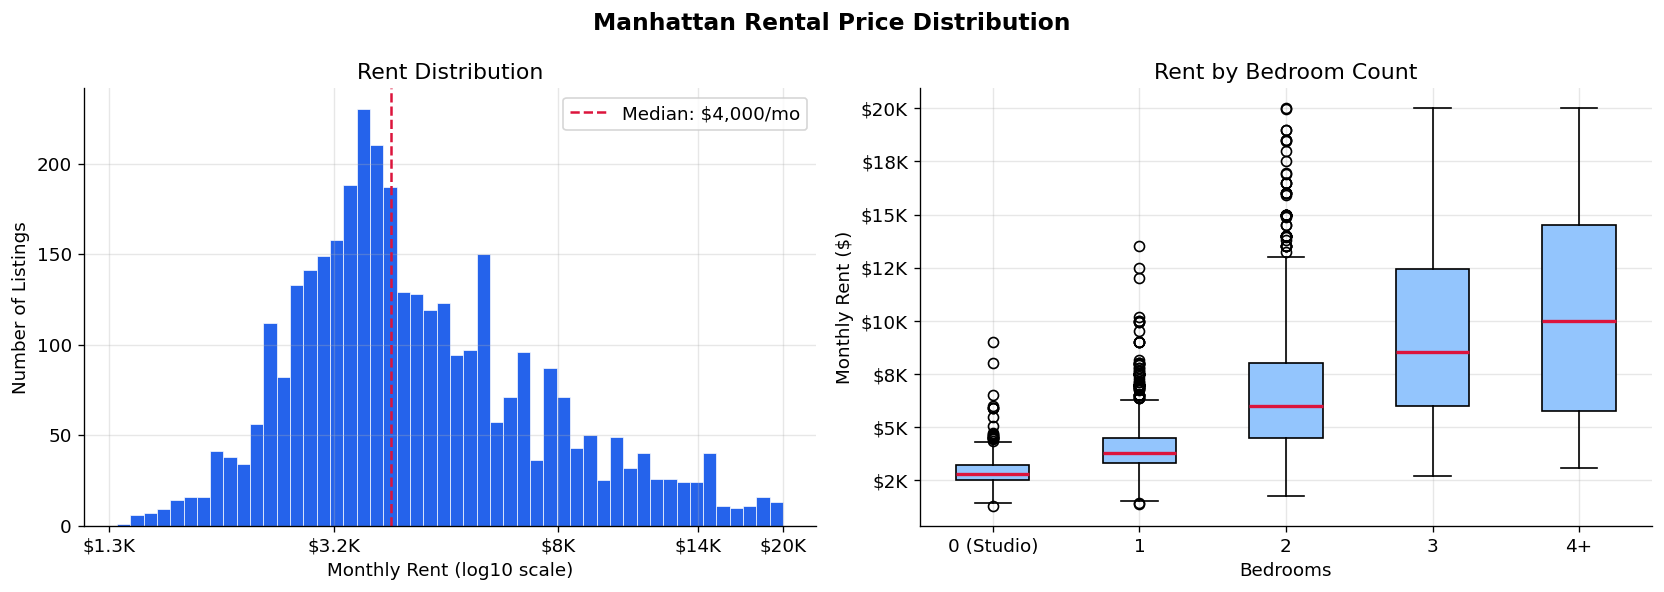

Rent percentiles:
count     $3,526
mean      $5,146
std       $3,166
min       $1,300
10%       $2,550
25%       $3,150
50%       $4,000
75%       $6,000
90%       $9,226
95%      $12,000
99%      $17,188
max      $20,000
Name: rent, dtype: str


In [4]:
# EDA 1: Rent distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
log_rent = np.log10(df['rent'])
ax.hist(log_rent, bins=50, color=ACCENT, edgecolor='white', linewidth=0.4)
ticks = [3.1, 3.5, 3.9, 4.15, 4.3]
ax.set_xticks(ticks)
ax.set_xticklabels(['$1.3K', '$3.2K', '$8K', '$14K', '$20K'])
med_log = np.log10(df['rent'].median())
ax.axvline(med_log, color='crimson', linestyle='--', linewidth=1.5,
           label=f"Median: ${df['rent'].median():,.0f}/mo")
ax.set_xlabel('Monthly Rent (log10 scale)')
ax.set_ylabel('Number of Listings')
ax.set_title('Rent Distribution')
ax.legend()

ax2 = axes[1]
df['BD_GROUP'] = df['bedrooms'].apply(
    lambda x: '0 (Studio)' if x < 1 else ('4+' if x >= 4 else str(int(x))))
bd_order = ['0 (Studio)', '1', '2', '3', '4+']
data_by_bd = [df.loc[df['BD_GROUP'] == b, 'rent'] for b in bd_order]
bp = ax2.boxplot(data_by_bd, tick_labels=bd_order, patch_artist=True,
                 medianprops=dict(color='crimson', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor(SOFT)
ax2.set_xlabel('Bedrooms')
ax2.set_ylabel('Monthly Rent ($)')
ax2.set_title('Rent by Bedroom Count')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))

plt.suptitle('Manhattan Rental Price Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Manhattan Rental Price Distribution.png')
plt.show()


print('Rent percentiles:')
print(df['rent'].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99])
      .apply(lambda x: f'${x:,.0f}'))

Corr(size_sqft, rent): 0.8579
Corr(floor,     rent): 0.2158


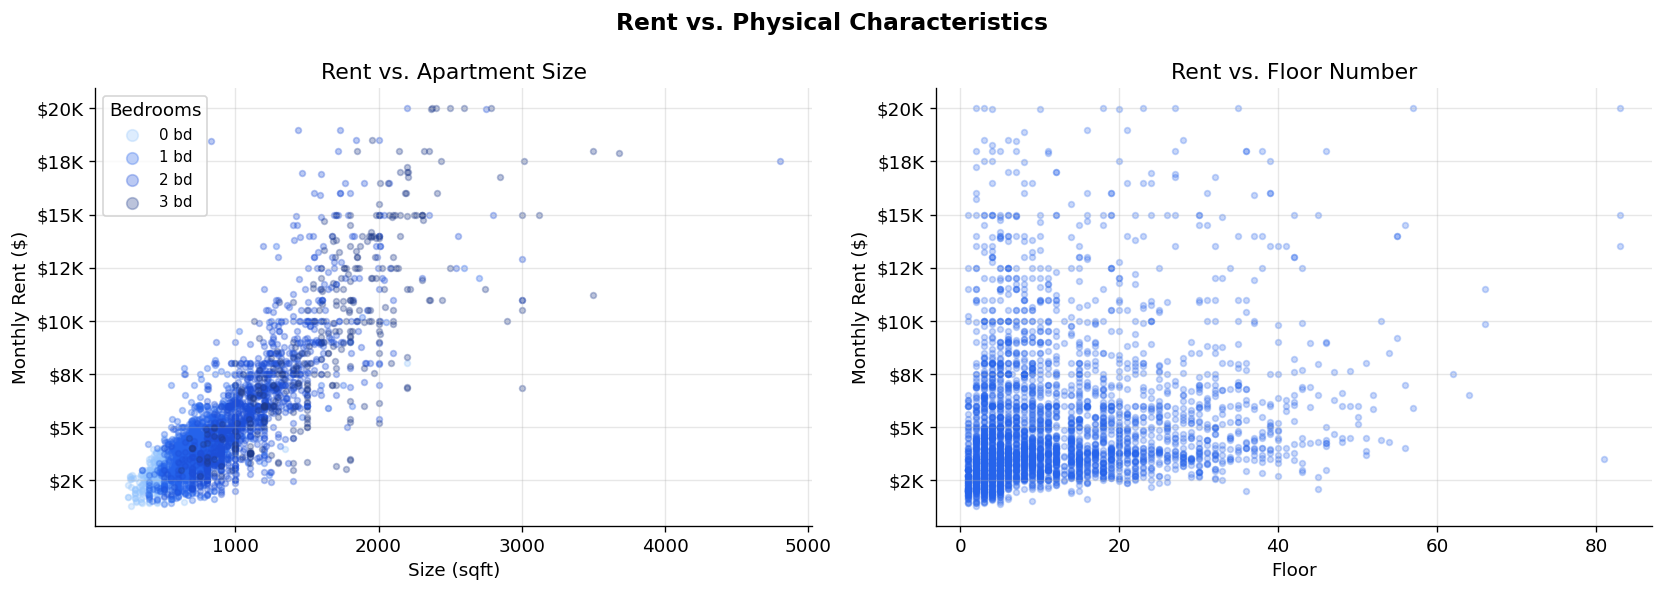

In [5]:
# EDA 2: Rent vs. size_sqft and floor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for bd, color in [(0,'#93C5FD'),(1,ACCENT),(2,'#1D4ED8'),(3,'#1e3a8a')]:
    mask = (df['bedrooms'] >= bd) & (df['bedrooms'] < bd+1)
    ax.scatter(df.loc[mask,'size_sqft'], df.loc[mask,'rent'],
               color=color, alpha=0.3, s=12, label=f'{bd} bd')
ax.set_xlabel('Size (sqft)')
ax.set_ylabel('Monthly Rent ($)')
ax.set_title('Rent vs. Apartment Size')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))
ax.legend(title='Bedrooms', fontsize=9, markerscale=2)

ax2 = axes[1]
ax2.scatter(df['floor'], df['rent'], color=ACCENT, alpha=0.25, s=12)
ax2.set_xlabel('Floor')
ax2.set_ylabel('Monthly Rent ($)')
ax2.set_title('Rent vs. Floor Number')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))

corr_sqft  = df['size_sqft'].corr(df['rent'])
corr_floor = df['floor'].corr(df['rent'])
print(f'Corr(size_sqft, rent): {corr_sqft:.4f}')
print(f'Corr(floor,     rent): {corr_floor:.4f}')

plt.suptitle('Rent vs. Physical Characteristics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Rent vs Physical Characteristics.png')
plt.show()


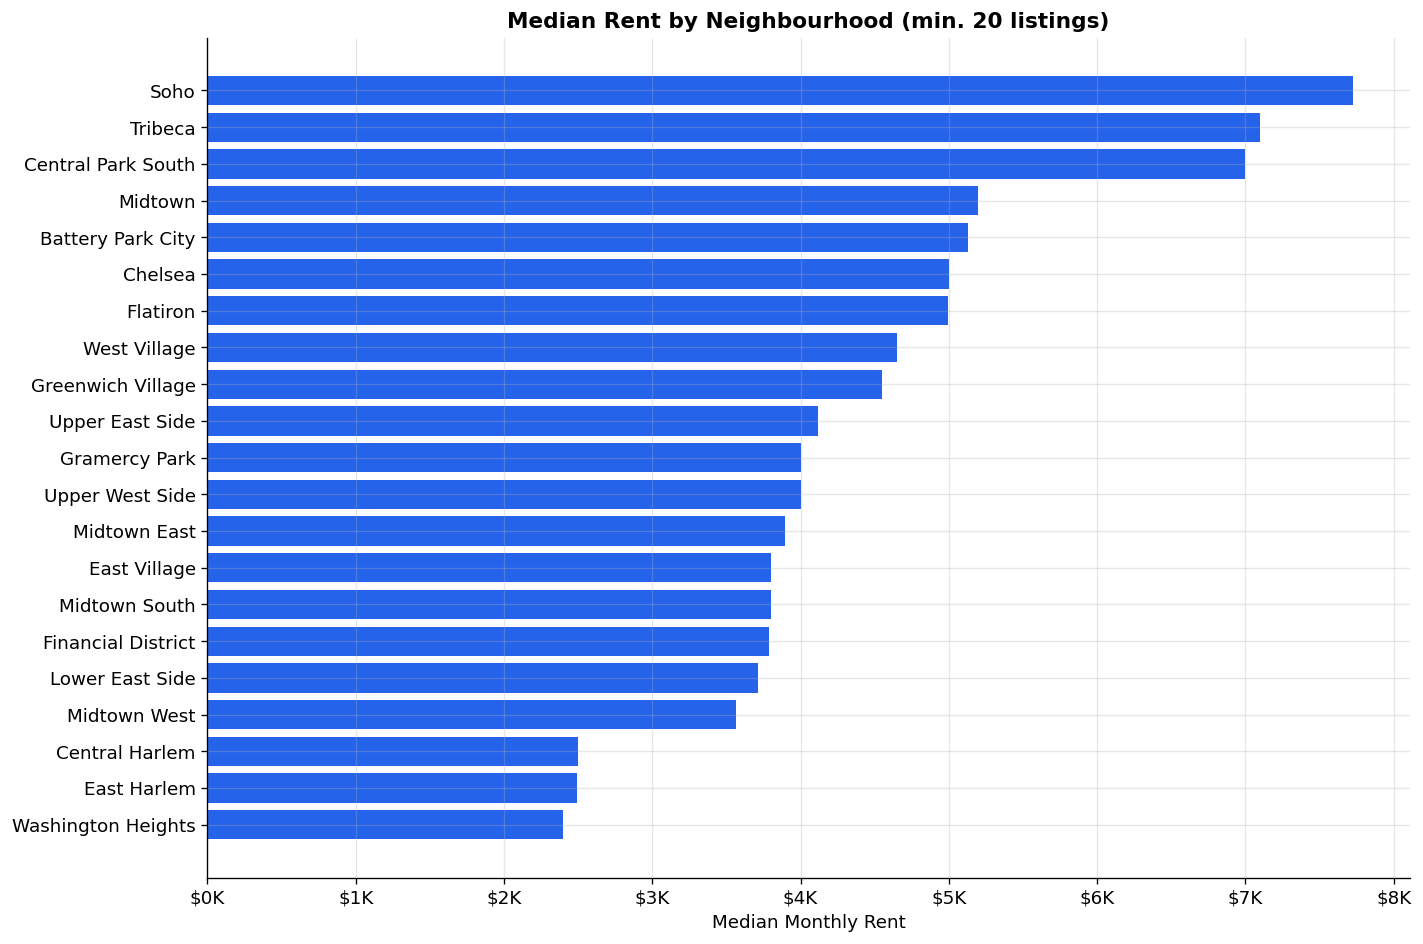

                   median_rent  count
neighborhood                         
Soho                    $7,722     58
Tribeca                 $7,100    119
Central Park South      $6,995     23
Midtown                 $5,200    119
Battery Park City       $5,128    104
Chelsea                 $5,000    182
Flatiron                $4,995    132
West Village            $4,650     67
Greenwich Village       $4,548     66
Upper East Side         $4,114    498
Gramercy Park           $4,000     61
Upper West Side         $4,000    577
Midtown East            $3,895    457
East Village            $3,800    108
Midtown South           $3,800     85
Financial District      $3,786    267
Lower East Side         $3,712     41
Midtown West            $3,564    314
Central Harlem          $2,500     82
East Harlem             $2,495     41
Washington Heights      $2,400     54


In [6]:
# EDA 3: Median rent by neighbourhood
neigh_stats = (df.groupby('neighborhood')
               .agg(median_rent=('rent','median'), count=('rent','count'))
               .query('count >= 20')
               .sort_values('median_rent', ascending=False))

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(neigh_stats.index[::-1], neigh_stats['median_rent'][::-1], color=ACCENT)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))
ax.set_xlabel('Median Monthly Rent')
ax.set_title('Median Rent by Neighbourhood (min. 20 listings)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Median Rent by Neighbourhood.png')
plt.show()


print(neigh_stats[['median_rent','count']]
      .assign(median_rent=lambda x: x['median_rent'].apply(lambda v: f'${v:,.0f}'))
      .to_string())

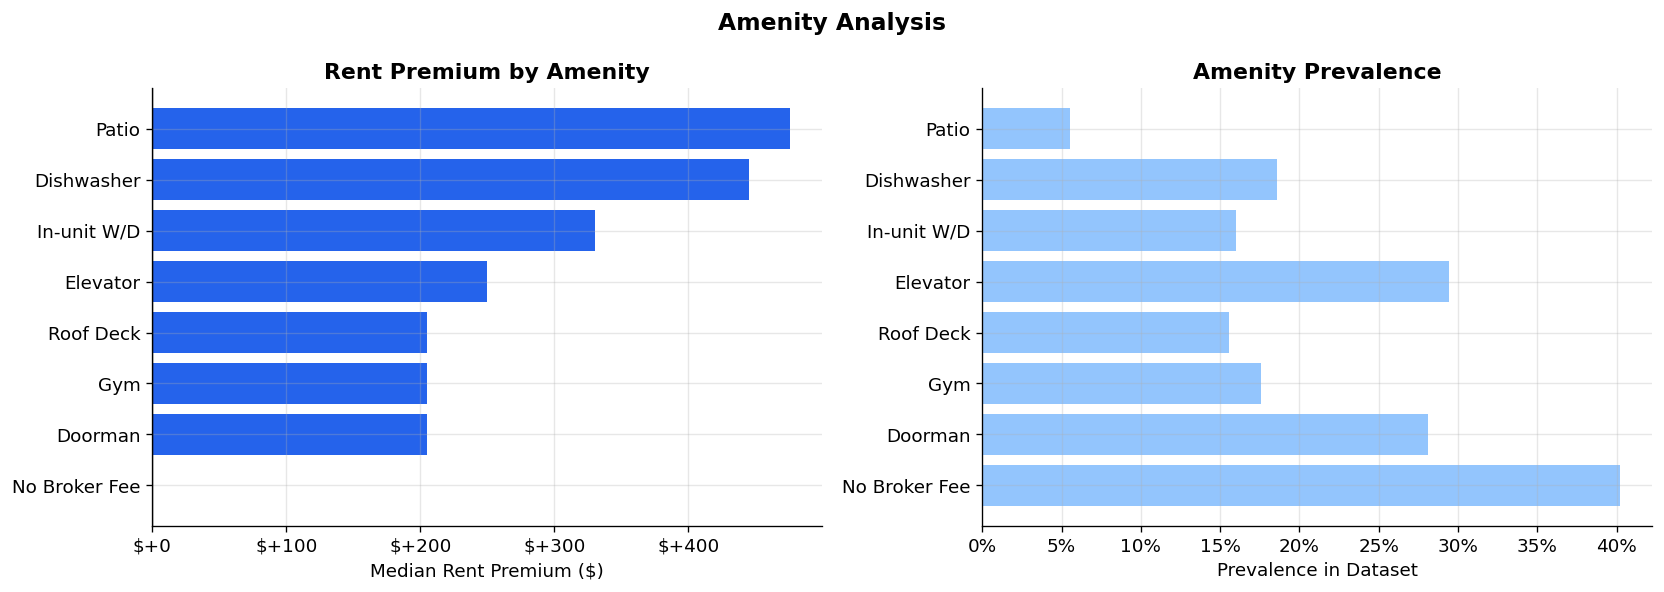

      Amenity Premium Prevalence   With Without
        Patio   $+476       5.5% $4,475  $3,999
   Dishwasher   $+445      18.6% $4,400  $3,955
  In-unit W/D   $+330      16.0% $4,300  $3,970
     Elevator   $+250      29.4% $4,200  $3,950
      Doorman   $+205      28.1% $4,200  $3,995
          Gym   $+205      17.6% $4,200  $3,995
    Roof Deck   $+205      15.5% $4,200  $3,995
No Broker Fee     $+0      40.2% $4,000  $4,000


In [7]:
# EDA 4: Amenity rent premium
amenities = {
    'no_fee': 'No Broker Fee',
    'has_doorman': 'Doorman',
    'has_elevator': 'Elevator',
    'has_gym': 'Gym',
    'has_washer_dryer': 'In-unit W/D',
    'has_dishwasher': 'Dishwasher',
    'has_roofdeck': 'Roof Deck',
    'has_patio': 'Patio',
}

premiums = []
for col, label in amenities.items():
    with_a    = df[df[col] == 1]['rent'].median()
    without_a = df[df[col] == 0]['rent'].median()
    premiums.append({'Amenity': label, 'Premium': with_a - without_a,
                     'Prevalence': df[col].mean(), 'With': with_a, 'Without': without_a})

prem_df = pd.DataFrame(premiums).sort_values('Premium', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = [ACCENT if v >= 0 else 'crimson' for v in prem_df['Premium']]
ax.barh(prem_df['Amenity'], prem_df['Premium'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v:+,.0f}'))
ax.set_xlabel('Median Rent Premium ($)')
ax.set_title('Rent Premium by Amenity', fontweight='bold')

ax2 = axes[1]
ax2.barh(prem_df['Amenity'], prem_df['Prevalence'], color=SOFT)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0%}'))
ax2.set_xlabel('Prevalence in Dataset')
ax2.set_title('Amenity Prevalence', fontweight='bold')

plt.suptitle('Amenity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Amenity Analysis.png')
plt.show()

print(prem_df[['Amenity','Premium','Prevalence','With','Without']]
      .assign(Premium=lambda x: x['Premium'].apply(lambda v: f'${v:+,.0f}'),
              Prevalence=lambda x: x['Prevalence'].apply(lambda v: f'{v:.1%}'),
              With=lambda x: x['With'].apply(lambda v: f'${v:,.0f}'),
              Without=lambda x: x['Without'].apply(lambda v: f'${v:,.0f}'))
      .sort_values('Premium', ascending=False).to_string(index=False))

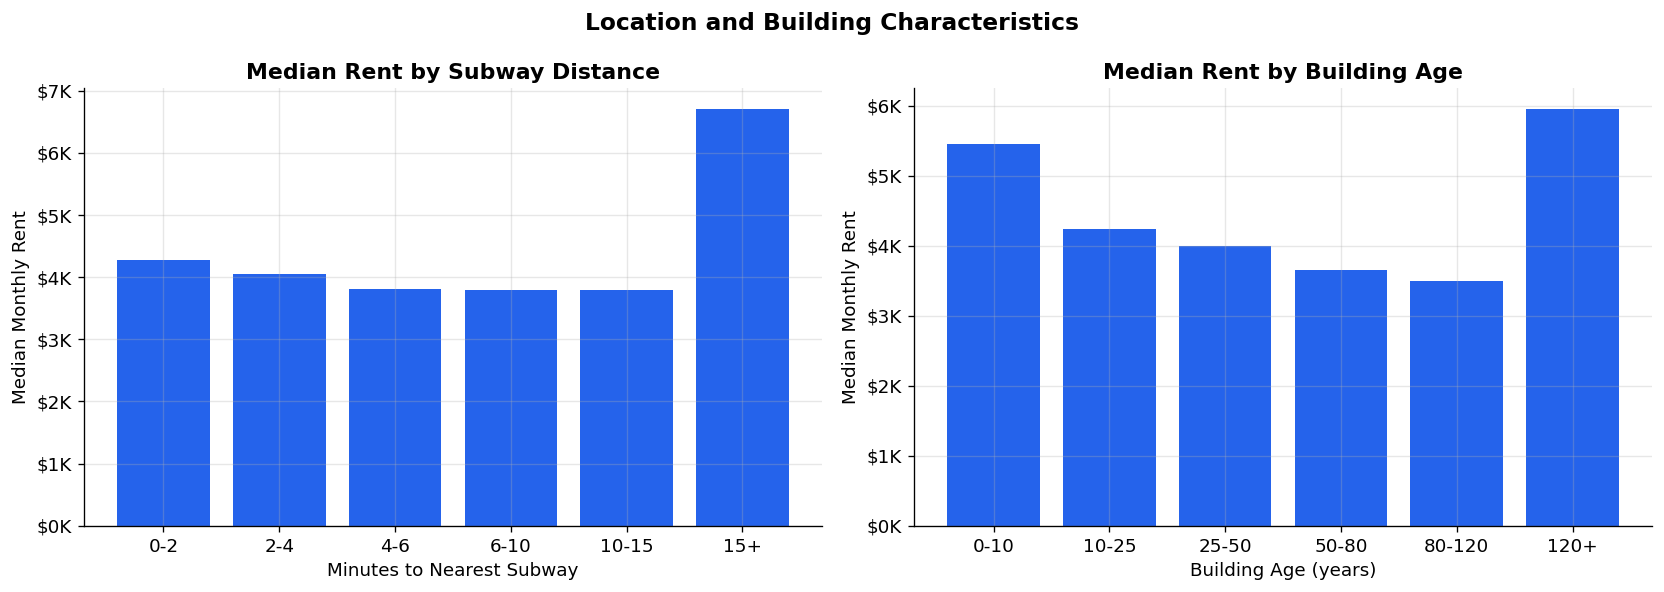

Corr(min_to_subway,   rent): 0.0357
Corr(building_age_yrs, rent): -0.1295


In [8]:
# EDA 5: Subway proximity and building age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Median rent by subway bin
ax = axes[0]
bins   = [0, 2, 4, 6, 10, 15, 45]
labels = ['0-2', '2-4', '4-6', '6-10', '10-15', '15+']
df['SUBWAY_BIN'] = pd.cut(df['min_to_subway'], bins=bins, labels=labels)
subway_med = df.groupby('SUBWAY_BIN', observed=True)['rent'].median()
ax.bar(subway_med.index, subway_med.values, color=ACCENT)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))
ax.set_xlabel('Minutes to Nearest Subway')
ax.set_ylabel('Median Monthly Rent')
ax.set_title('Median Rent by Subway Distance', fontweight='bold')

# Median rent by building age bin
ax2 = axes[1]
age_bins   = [0, 10, 25, 50, 80, 120, 200]
age_labels = ['0-10', '10-25', '25-50', '50-80', '80-120', '120+']
df['AGE_BIN'] = pd.cut(df['building_age_yrs'], bins=age_bins, labels=age_labels)
age_med = df.groupby('AGE_BIN', observed=True)['rent'].median()
ax2.bar(age_med.index, age_med.values, color=ACCENT)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1e3:.0f}K'))
ax2.set_xlabel('Building Age (years)')
ax2.set_ylabel('Median Monthly Rent')
ax2.set_title('Median Rent by Building Age', fontweight='bold')

plt.suptitle('Location and Building Characteristics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Location and Building Characteristics.png')
plt.show()

print(f"Corr(min_to_subway,   rent): {df['min_to_subway'].corr(df['rent']):.4f}")
print(f"Corr(building_age_yrs, rent): {df['building_age_yrs'].corr(df['rent']):.4f}")

## Feature Engineering

In [9]:
# Target variable: log-transform rent
df['LOG_RENT'] = np.log1p(df['rent'])

print(f'Rent skewness:          {df["rent"].skew():.3f}')
print(f'Log-rent skewness:      {df["LOG_RENT"].skew():.3f}')

# Feature list
FEATURES = [
    # Unit characteristics
    'size_sqft', 'bedrooms', 'bathrooms', 'floor',
    'building_age_yrs', 'min_to_subway',
    # Amenity flags (already binary integers — no encoding needed)
    'no_fee', 'has_roofdeck', 'has_washer_dryer', 'has_doorman',
    'has_elevator', 'has_dishwasher', 'has_patio', 'has_gym',
    # Location (target-encoded post-split)
    'NEIGH_TARGET_ENC',
]
TARGET = 'LOG_RENT'

print(f'\nFeature count: {len(FEATURES)}')
print(f'Target:        {TARGET}')

Rent skewness:          1.980
Log-rent skewness:      0.646

Feature count: 15
Target:        LOG_RENT


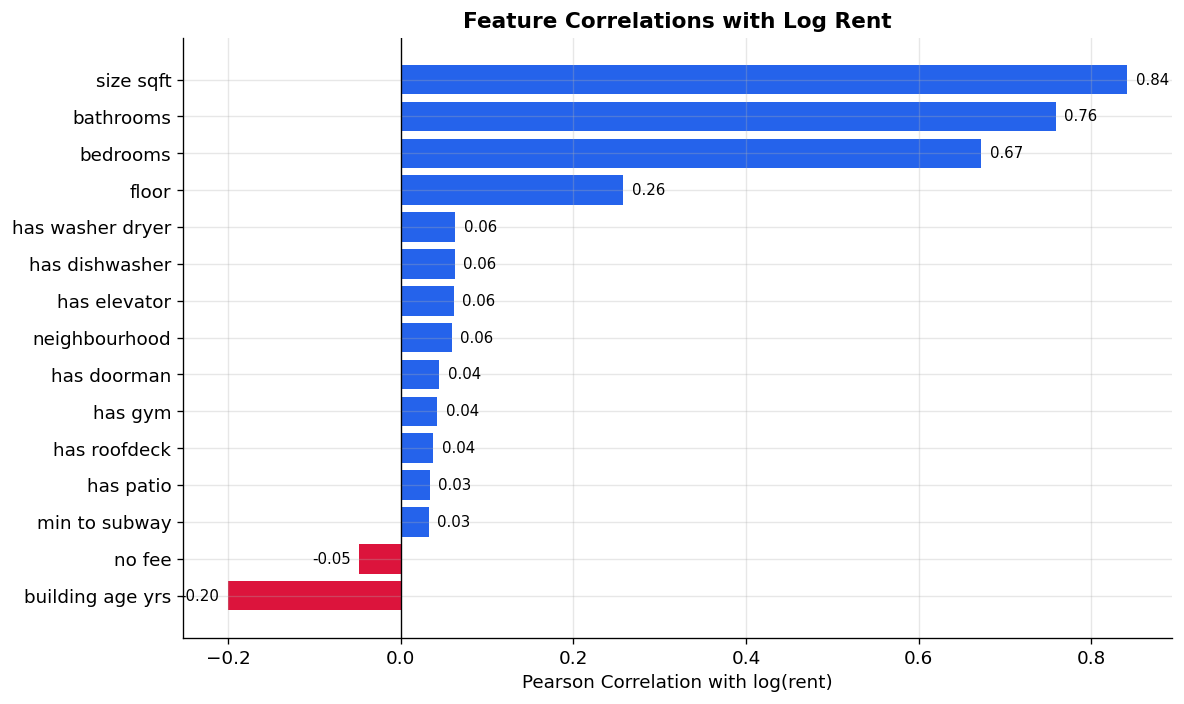

Correlations with LOG_RENT:
size sqft            0.8418
bathrooms            0.7588
bedrooms             0.6727
floor                0.2574
has washer dryer     0.0629
has dishwasher       0.0622
has elevator         0.0611
neighbourhood        0.0590
has doorman          0.0443
has gym              0.0424
has roofdeck         0.0377
has patio            0.0334
min to subway        0.0324
no fee              -0.0481
building age yrs    -0.2003


In [10]:
# Feature correlations with LOG_RENT
from sklearn.preprocessing import LabelEncoder
_le = LabelEncoder()
df['_NEIGH_NUM'] = _le.fit_transform(df['neighborhood'])

corr_cols = ['size_sqft','bedrooms','bathrooms','floor','building_age_yrs',
             'min_to_subway','no_fee','has_roofdeck','has_washer_dryer',
             'has_doorman','has_elevator','has_dishwasher','has_patio','has_gym',
             '_NEIGH_NUM']

corr = (df[corr_cols + ['LOG_RENT']]
        .corr()['LOG_RENT'].drop('LOG_RENT').sort_values())
corr.index = [i.replace('_NEIGH_NUM','neighbourhood').replace('_',' ')
              for i in corr.index]

fig, ax = plt.subplots(figsize=(10, 6))
colors = [ACCENT if v >= 0 else 'crimson' for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with log(rent)')
ax.set_title('Feature Correlations with Log Rent', fontsize=13, fontweight='bold')
for bar, val in zip(bars, corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('Feature Correlations with Log Rent.png')
plt.show()

df.drop(columns=['_NEIGH_NUM'], inplace=True)
print('Correlations with LOG_RENT:')
print(corr.sort_values(ascending=False).apply(lambda x: f'{x:.4f}').to_string())

## Train / Validation / Test Split

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Random 70/15/15 split
df['BD_STRAT'] = df['bedrooms'].clip(upper=3).astype(str)

X_base = df[FEATURES[:-1]]  # all features except NEIGH_TARGET_ENC placeholder
y      = df[TARGET]

X_temp, X_test, y_temp, y_test = train_test_split(
    X_base, y, test_size=0.15, random_state=42, stratify=df['BD_STRAT'])
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42,
    stratify=df.loc[X_temp.index, 'BD_STRAT'])

print(f'Train : {len(X_train):>5,} rows ({len(X_train)/len(df):.1%})')
print(f'Val   : {len(X_val):>5,} rows ({len(X_val)/len(df):.1%})')
print(f'Test  : {len(X_test):>5,} rows ({len(X_test)/len(df):.1%})')

# Neighbourhood target encoding
neigh_enc_map = (df.loc[X_train.index]
                 .groupby(df.loc[X_train.index, 'neighborhood'])['LOG_RENT'].mean())
global_mean   = df.loc[X_train.index, 'LOG_RENT'].mean()

def apply_enc(idx):
    return df.loc[idx, 'neighborhood'].map(neigh_enc_map).fillna(global_mean)

X_train = X_train.copy(); X_train['NEIGH_TARGET_ENC'] = apply_enc(X_train.index)
X_val   = X_val.copy();   X_val['NEIGH_TARGET_ENC']   = apply_enc(X_val.index)
X_test  = X_test.copy();  X_test['NEIGH_TARGET_ENC']  = apply_enc(X_test.index)

print(f'\nNeighbourhood encoding fitted on {len(X_train):,} training rows.')
print(f'Unique neighbourhoods in training set: {neigh_enc_map.shape[0]}')

# Imputation
imputer     = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=FEATURES)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),        columns=FEATURES)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),       columns=FEATURES)

# Scaling (for Linear Regression, SVR, Neural Network)
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train_imp)
X_val_sc    = scaler.transform(X_val_imp)
X_test_sc   = scaler.transform(X_test_imp)

print(f'Remaining nulls in X_train_imp: {X_train_imp.isnull().sum().sum()}')
print('Split, encoding, imputation, and scaling complete.')

Train : 2,469 rows (70.0%)
Val   :   528 rows (15.0%)
Test  :   529 rows (15.0%)

Neighbourhood encoding fitted on 2,469 training rows.
Unique neighbourhoods in training set: 31
Remaining nulls in X_train_imp: 0
Split, encoding, imputation, and scaling complete.


## Model Training and Evaluation

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}

def evaluate(name, model, X_val_data, X_test_data, log=True):

    scores = {}
    for split_name, X, y in [('val', X_val_data, y_val), ('test', X_test_data, y_test)]:
        preds_log = model.predict(X)
        if log:
            preds   = np.expm1(preds_log)
            actuals = np.expm1(y)
        else:
            preds, actuals = preds_log, y
        rmse = np.sqrt(mean_squared_error(actuals, preds))
        mae  = mean_absolute_error(actuals, preds)
        r2   = r2_score(y, preds_log)
        scores[split_name] = dict(RMSE=rmse, MAE=mae, R2=r2)
    results[name] = scores
    print(f"\n{'─'*58}")
    print(f'  {name}')
    print(f"{'─'*58}")
    for sn, m in scores.items():
        print(f"  {sn.upper():5s}  RMSE=${m['RMSE']:>7,.0f}  "
              f"MAE=${m['MAE']:>7,.0f}  R2(log)={m['R2']:.4f}")
    return scores

print('Metrics: RMSE and MAE in dollars, R2 on log-space predictions.')

Metrics: RMSE and MAE in dollars, R2 on log-space predictions.


In [13]:
# MODEL 1 — LINEAR REGRESSION

from sklearn.linear_model import LinearRegression, Ridge

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
evaluate('Linear Regression (OLS)', lr, X_val_sc, X_test_sc)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
evaluate('Linear Regression (Ridge a=1)', ridge, X_val_sc, X_test_sc)

coef_df = pd.DataFrame({'feature': FEATURES, 'coef': ridge.coef_})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)
print(f'\nTop 10 Ridge coefficients (by magnitude):')
print(coef_df.head(10).to_string(index=False))


──────────────────────────────────────────────────────────
  Linear Regression (OLS)
──────────────────────────────────────────────────────────
  VAL    RMSE=$  2,938  MAE=$  1,066  R2(log)=0.8207
  TEST   RMSE=$  1,962  MAE=$    888  R2(log)=0.8443

──────────────────────────────────────────────────────────
  Linear Regression (Ridge a=1)
──────────────────────────────────────────────────────────
  VAL    RMSE=$  2,930  MAE=$  1,066  R2(log)=0.8208
  TEST   RMSE=$  1,960  MAE=$    888  R2(log)=0.8444

Top 10 Ridge coefficients (by magnitude):
         feature      coef
       size_sqft  0.297131
NEIGH_TARGET_ENC  0.133494
building_age_yrs -0.068939
       bathrooms  0.065646
           floor  0.056189
        bedrooms  0.055388
   min_to_subway -0.020318
          no_fee  0.012696
has_washer_dryer  0.009512
         has_gym -0.008440


In [14]:
# MODEL 2 — DECISION TREE REGRESSION

from sklearn.tree import DecisionTreeRegressor

dt_shallow = DecisionTreeRegressor(max_depth=6, min_samples_leaf=20, random_state=42)
dt_shallow.fit(X_train_imp, y_train)
evaluate('Decision Tree (max_depth=6)', dt_shallow, X_val_imp, X_test_imp)

dt_deep = DecisionTreeRegressor(max_depth=15, min_samples_leaf=5, random_state=42)
dt_deep.fit(X_train_imp, y_train)
evaluate('Decision Tree (max_depth=15)', dt_deep, X_val_imp, X_test_imp)

fi_dt = pd.Series(dt_deep.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(f'\nTop 10 Decision Tree feature importances:')
print(fi_dt.head(10).apply(lambda x: f'{x:.4f}').to_string())


──────────────────────────────────────────────────────────
  Decision Tree (max_depth=6)
──────────────────────────────────────────────────────────
  VAL    RMSE=$  1,715  MAE=$    942  R2(log)=0.8355
  TEST   RMSE=$  1,366  MAE=$    801  R2(log)=0.8538

──────────────────────────────────────────────────────────
  Decision Tree (max_depth=15)
──────────────────────────────────────────────────────────
  VAL    RMSE=$  1,658  MAE=$    883  R2(log)=0.8453
  TEST   RMSE=$  1,224  MAE=$    754  R2(log)=0.8692

Top 10 Decision Tree feature importances:
size_sqft           0.8173
NEIGH_TARGET_ENC    0.1047
building_age_yrs    0.0402
floor               0.0135
min_to_subway       0.0089
bedrooms            0.0053
no_fee              0.0035
bathrooms           0.0033
has_washer_dryer    0.0011
has_doorman         0.0009


In [15]:
# MODEL 3 — RANDOM FOREST

from sklearn.ensemble import RandomForestRegressor

print('Training Random Forest (this may take ~1 minute)...')
rf = RandomForestRegressor(
    n_estimators=200, max_depth=20, min_samples_leaf=5,
    max_features=0.5, n_jobs=-1, random_state=42)
rf.fit(X_train_imp, y_train)
evaluate('Random Forest (n=200, depth=20)', rf, X_val_imp, X_test_imp)

fi_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(f'\nTop 10 Random Forest feature importances:')
print(fi_rf.head(10).apply(lambda x: f'{x:.4f}').to_string())

Training Random Forest (this may take ~1 minute)...

──────────────────────────────────────────────────────────
  Random Forest (n=200, depth=20)
──────────────────────────────────────────────────────────
  VAL    RMSE=$  1,504  MAE=$    778  R2(log)=0.8848
  TEST   RMSE=$  1,215  MAE=$    696  R2(log)=0.8990

Top 10 Random Forest feature importances:
size_sqft           0.5239
bathrooms           0.1994
NEIGH_TARGET_ENC    0.0972
bedrooms            0.0924
building_age_yrs    0.0423
floor               0.0257
min_to_subway       0.0098
no_fee              0.0041
has_elevator        0.0011
has_doorman         0.0011


In [16]:
# MODEL 4 — SUPPORT VECTOR REGRESSION (SVR)

from sklearn.svm import SVR

SVR_SAMPLE = 2000
np.random.seed(42)
svr_idx = np.random.choice(len(X_train_sc), size=SVR_SAMPLE, replace=False)

print(f'Training SVR on {SVR_SAMPLE:,} sample rows '
      f'({SVR_SAMPLE/len(X_train_sc):.0%} of training set)...')
svr = SVR(kernel='rbf', C=10, epsilon=0.05, gamma='scale')
svr.fit(X_train_sc[svr_idx], y_train.iloc[svr_idx])
evaluate('SVR (rbf, C=10, 2k sample)', svr, X_val_sc, X_test_sc)

Training SVR on 2,000 sample rows (81% of training set)...

──────────────────────────────────────────────────────────
  SVR (rbf, C=10, 2k sample)
──────────────────────────────────────────────────────────
  VAL    RMSE=$  1,794  MAE=$    940  R2(log)=0.8255
  TEST   RMSE=$  1,418  MAE=$    787  R2(log)=0.8573


{'val': {'RMSE': np.float64(1793.9870803015535),
  'MAE': 939.7108324735735,
  'R2': 0.8255464442163847},
 'test': {'RMSE': np.float64(1418.0996473783794),
  'MAE': 787.0911708832081,
  'R2': 0.8572686737094121}}

In [17]:
# MODEL 5 — XGBOOST

try:
    import xgboost as xgb
    print(f'XGBoost version: {xgb.__version__}')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    import xgboost as xgb

print('Training XGBoost with early stopping...')
xgb_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0,
    early_stopping_rounds=30, eval_metric='rmse',
    random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train_imp, y_train,
              eval_set=[(X_val_imp, y_val)], verbose=False)
print(f'Best iteration: {xgb_model.best_iteration}')
evaluate('XGBoost (early stopping)', xgb_model, X_val_imp, X_test_imp)

fi_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(f'\nTop 10 XGBoost feature importances:')
print(fi_xgb.head(10).apply(lambda x: f'{x:.4f}').to_string())

XGBoost version: 3.2.0
Training XGBoost with early stopping...
Best iteration: 270

──────────────────────────────────────────────────────────
  XGBoost (early stopping)
──────────────────────────────────────────────────────────
  VAL    RMSE=$  1,384  MAE=$    705  R2(log)=0.8991
  TEST   RMSE=$  1,188  MAE=$    652  R2(log)=0.9067

Top 10 XGBoost feature importances:
bathrooms           0.5750
size_sqft           0.2480
NEIGH_TARGET_ENC    0.0494
bedrooms            0.0322
building_age_yrs    0.0183
no_fee              0.0132
floor               0.0130
min_to_subway       0.0091
has_patio           0.0081
has_washer_dryer    0.0066


In [18]:
# MODEL 6 — NEURAL NETWORK

from sklearn.neural_network import MLPRegressor

print('Training Neural Network...')
nn = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam',
    learning_rate_init=0.001, batch_size=128, max_iter=300,
    early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=20, random_state=42, verbose=False)
nn.fit(X_train_sc, y_train)
print(f'Stopped after {nn.n_iter_} iterations')
evaluate('Neural Network (128-64-32)', nn, X_val_sc, X_test_sc)

Training Neural Network...
Stopped after 129 iterations

──────────────────────────────────────────────────────────
  Neural Network (128-64-32)
──────────────────────────────────────────────────────────
  VAL    RMSE=$  3,788  MAE=$  1,234  R2(log)=0.7781
  TEST   RMSE=$  1,970  MAE=$    933  R2(log)=0.8307


{'val': {'RMSE': np.float64(3787.6641991210277),
  'MAE': 1233.8631738279726,
  'R2': 0.7780536536373468},
 'test': {'RMSE': np.float64(1969.6372662537162),
  'MAE': 933.2928130695203,
  'R2': 0.8306556351324306}}

## Model Comparison

In [19]:
# Summary table
rows = []
for model_name, splits in results.items():
    for split_name, metrics in splits.items():
        rows.append({'Model': model_name, 'Split': split_name.upper(), **metrics})
summary = pd.DataFrame(rows)

print('=' * 88)
print(f"{'Model':<42} {'Split':<6} {'RMSE':>10} {'MAE':>10} {'R2(log)':>10}")
print('=' * 88)
for _, row in summary.iterrows():
    print(f"{row['Model']:<42} {row['Split']:<6} "
          f"${row['RMSE']:>9,.0f} ${row['MAE']:>9,.0f} {row['R2']:>10.4f}")
print('=' * 88)

Model                                      Split        RMSE        MAE    R2(log)
Linear Regression (OLS)                    VAL    $    2,938 $    1,066     0.8207
Linear Regression (OLS)                    TEST   $    1,962 $      888     0.8443
Linear Regression (Ridge a=1)              VAL    $    2,930 $    1,066     0.8208
Linear Regression (Ridge a=1)              TEST   $    1,960 $      888     0.8444
Decision Tree (max_depth=6)                VAL    $    1,715 $      942     0.8355
Decision Tree (max_depth=6)                TEST   $    1,366 $      801     0.8538
Decision Tree (max_depth=15)               VAL    $    1,658 $      883     0.8453
Decision Tree (max_depth=15)               TEST   $    1,224 $      754     0.8692
Random Forest (n=200, depth=20)            VAL    $    1,504 $      778     0.8848
Random Forest (n=200, depth=20)            TEST   $    1,215 $      696     0.8990
SVR (rbf, C=10, 2k sample)                 VAL    $    1,794 $      940     0.8255
SVR 

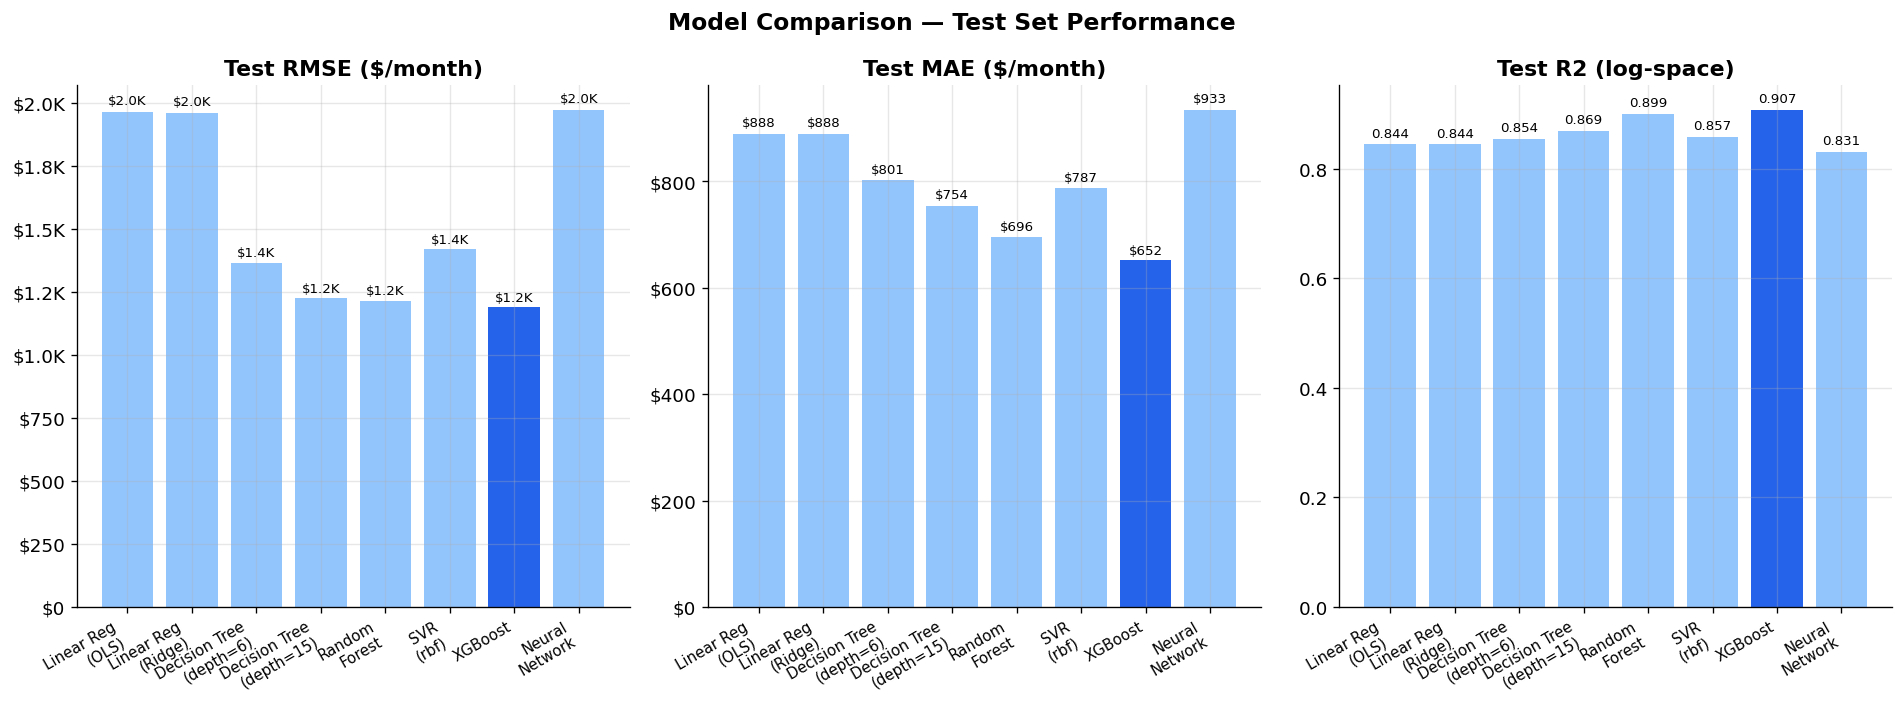


Best model by R2(log) on test set: XGBoost (early stopping)
  R2(log) = 0.9067
  RMSE    = $1,188/month
  MAE     = $652/month


In [20]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
test_res = summary[summary['Split'] == 'TEST'].set_index('Model')
models   = test_res.index.tolist()
x        = range(len(models))
label_map = {
    'Linear Regression (OLS)':         'Linear Reg\n(OLS)',
    'Linear Regression (Ridge a=1)':   'Linear Reg\n(Ridge)',
    'Decision Tree (max_depth=6)':     'Decision Tree\n(depth=6)',
    'Decision Tree (max_depth=15)':    'Decision Tree\n(depth=15)',
    'Random Forest (n=200, depth=20)': 'Random\nForest',
    'SVR (rbf, C=10, 2k sample)':      'SVR\n(rbf)',
    'XGBoost (early stopping)':        'XGBoost',
    'Neural Network (128-64-32)':      'Neural\nNetwork',
}
short    = [label_map.get(m, m.split('(')[0].strip()) for m in models]

def dollar_fmt(v, _):
    return f'${v/1e3:.1f}K' if v >= 1000 else f'${v:,.0f}'

for ax, metric, label in zip(
    axes,
    ['RMSE', 'MAE', 'R2'],
    ['RMSE ($/month)', 'MAE ($/month)', 'R2 (log-space)']):
    vals = test_res[metric].values
    best = min(vals) if metric != 'R2' else max(vals)
    colors = [ACCENT if v == best else SOFT for v in vals]
    bars = ax.bar(x, vals, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(short, rotation=30, ha='right', fontsize=9)
    ax.set_title(f'Test {label}', fontweight='bold')
    for bar, val in zip(bars, vals):
        lbl = dollar_fmt(val, None) if metric != 'R2' else f'{val:.3f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                lbl, ha='center', va='bottom', fontsize=8)
    if metric in ['RMSE','MAE']:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))

plt.suptitle('Model Comparison — Test Set Performance',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Model Comparison.png')
plt.show()

best = test_res['R2'].idxmax()
print(f'\nBest model by R2(log) on test set: {best}')
print(f"  R2(log) = {test_res.loc[best,'R2']:.4f}")
print(f"  RMSE    = ${test_res.loc[best,'RMSE']:,.0f}/month")
print(f"  MAE     = ${test_res.loc[best,'MAE']:,.0f}/month")

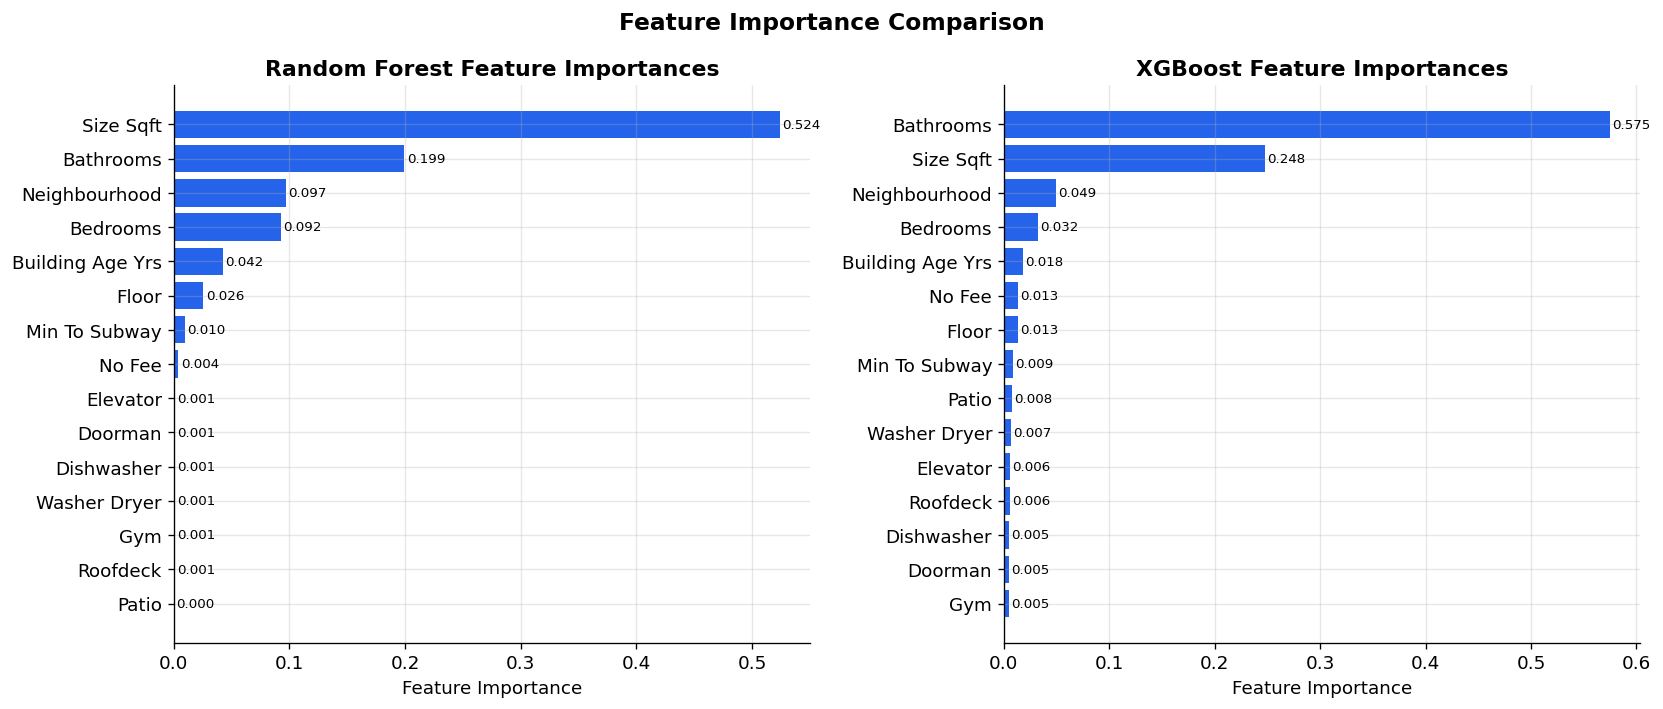

In [21]:
# Feature importance — Random Forest and XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, fi_series, title in [
    (axes[0], pd.Series(rf.feature_importances_,      index=FEATURES), 'Random Forest'),
    (axes[1], pd.Series(xgb_model.feature_importances_, index=FEATURES), 'XGBoost'),
]:
    fi = fi_series.sort_values()
    clean = [f.replace('_',' ').replace('has ','').replace('NEIGH TARGET ENC','Neighbourhood').title()
             for f in fi.index]
    ax.barh(clean, fi.values, color=ACCENT)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{title} Feature Importances', fontweight='bold')
    for i, (val, label) in enumerate(zip(fi.values, clean)):
        ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Feature Importance Comparison.png')
plt.show()